In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

In [21]:
PROJECT_PATH = Path("../").resolve()
DATA_PATH = PROJECT_PATH / "data"
DATA_TRAINING_SET_PATH = DATA_PATH / "UNSW_NB15_training-set.csv"

In [22]:
df_train = pd.read_csv(DATA_TRAINING_SET_PATH)

In [23]:
num_features = df_train.select_dtypes(include=np.number).columns.to_list()
cat_features = df_train.select_dtypes(include=["object", str]).columns.to_list()

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                [
                    ("imp", SimpleImputer(strategy="median")),
                    ("scal", MinMaxScaler()),
                ]
            ),
            num_features,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("imp", SimpleImputer(strategy="constant", fill_value="missing")),
                    ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]
            ),
            cat_features,
        ),
    ]
)

pipeline_full_pca = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("pca", PCA()),
    ]
)

In [25]:
X_all = pipeline_full_pca.fit_transform(df_train)

pca_step = pipeline_full_pca.named_steps["pca"]
valeurs_propres = pca_step.explained_variance_
variance_cumulee = np.cumsum(pca_step.explained_variance_ratio_) * 100
n_total = len(valeurs_propres)

pca_step = pipeline_full_pca.named_steps["pca"]
valeurs_propres = pca_step.explained_variance_
variance_cumulee = np.cumsum(pca_step.explained_variance_ratio_) * 100

nb_kaiser = np.sum(valeurs_propres > 1)

nb_90 = np.argmax(variance_cumulee >= 90) + 1

nb_80 = np.argmax(variance_cumulee >= 80) + 1

print("\n--- Bilan de la sélection (Hors affichage) ---")
print(f"Nombre total de dimensions possibles : {n_total}")
print(f"Critère de Kaiser (>1)               : {nb_kaiser} composantes sélectionnées")
print(f"Seuil de 80% de variance             : {nb_80} composantes sélectionnées")
print(f"Seuil de 90% de variance             : {nb_90} composantes sélectionnées")


--- Bilan de la sélection (Hors affichage) ---
Nombre total de dimensions possibles : 202
Critère de Kaiser (>1)               : 1 composantes sélectionnées
Seuil de 80% de variance             : 7 composantes sélectionnées
Seuil de 90% de variance             : 13 composantes sélectionnées


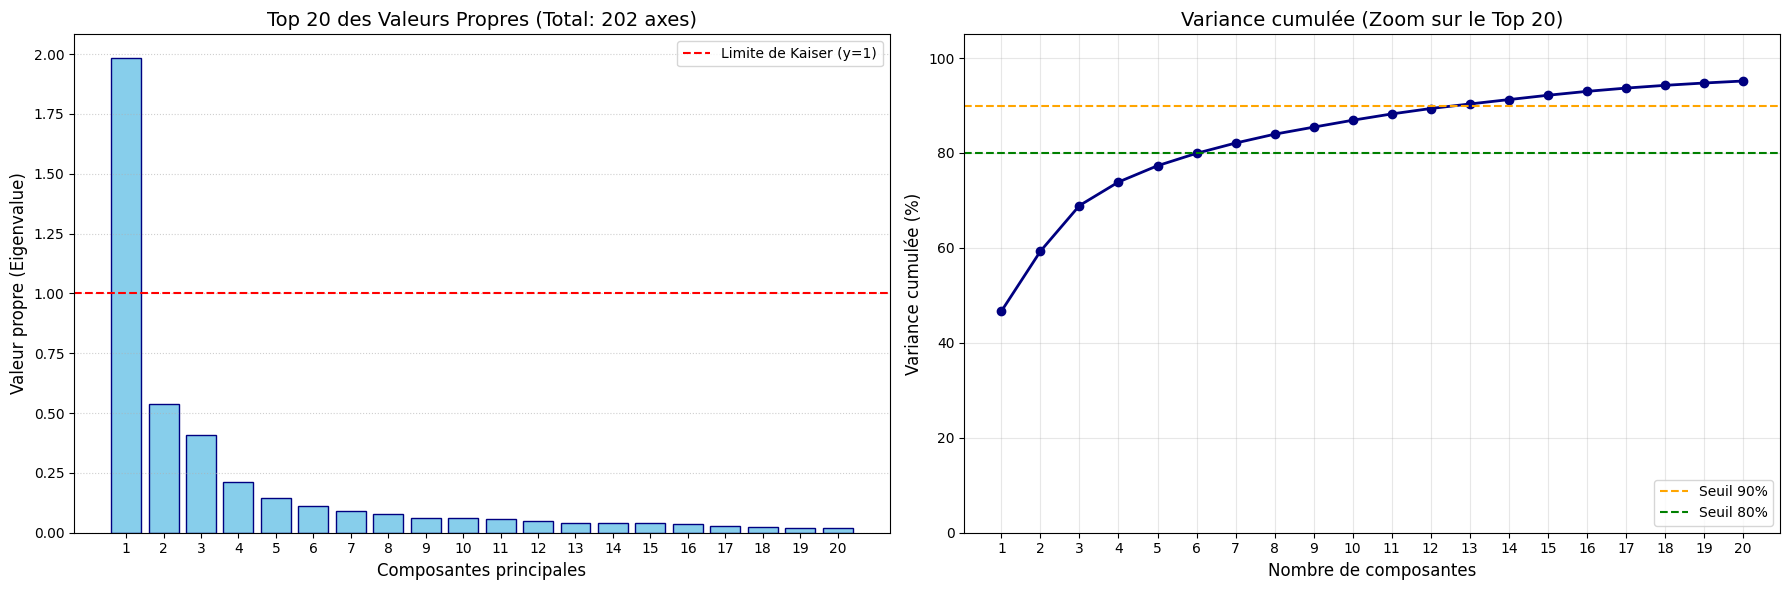

Dimensions totales générées : 202
Information conservée avec 20 composantes : 95.16%


In [ ]:
n_zoom = 20
n_total = len(valeurs_propres)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].bar(
    range(1, n_zoom + 1), valeurs_propres[:n_zoom], color="skyblue", edgecolor="navy"
)
axes[0].axhline(y=1, color="red", linestyle="--", label="Limite de Kaiser (y=1)")
axes[0].set_xticks(range(1, n_zoom + 1))
axes[0].set_xlabel("Composantes principales", fontsize=12)
axes[0].set_ylabel("Valeur propre (Eigenvalue)", fontsize=12)
axes[0].set_title(f"Top 20 des Valeurs Propres (Total: {n_total} axes)", fontsize=14)
axes[0].legend()
axes[0].grid(axis="y", linestyle=":", alpha=0.6)

axes[1].plot(
    range(1, n_zoom + 1),
    variance_cumulee[:n_zoom],
    color="navy",
    marker="o",
    linewidth=2,
)
axes[1].axhline(y=90, color="orange", linestyle="--", label="Seuil 90%")
axes[1].axhline(y=80, color="green", linestyle="--", label="Seuil 80%")

axes[1].set_xticks(range(1, n_zoom + 1))
axes[1].set_ylim(0, 105)
axes[1].set_xlabel("Nombre de composantes", fontsize=12)
axes[1].set_ylabel("Variance cumulée (%)", fontsize=12)
axes[1].set_title("Variance cumulée (Zoom sur le Top 20)", fontsize=14)
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Dimensions totales générées : {n_total}")
print(f"Information conservée avec 20 composantes : {variance_cumulee[19]:.2f}%")